<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/PreprocesamientoNormalizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de preprocesamiento y normalización de texto

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 18 de febrero de 2026




**Actividad:** Preparar los datos textuales para que puedan ser analizados o utilizados de manera más eficiente por algoritmos de procesamiento de lenguaje natural (PLN) o modelos de aprendizaje automático

Realizar lo siguiente en un script de Python:<br>
- Genere un script en Python donde aplique las técnicas de preprocesamiento y normalización de texto al dataset indicado (archivo tuits_cambio_climatico.csv) para mostrar en una gráﬁca de barras las primeras 20 palabras con mayor frecuencia y mostrar una nube de palabras.
- No muestre palabras que no aporten algún sentido a los tuits, muestre solo palabras relevantes.
- Para implementar el script utilice funciones.
- El texto de los tuits está almacenado en la columna llamada ‘tuit’ del dataset.
- Para leer los tuits utiliza/investiga la librería Pandas.


### Instalar librería Emoji, Stanza y modelo en español

In [14]:
!pip install emoji
!pip install stanza
stanza.download('es')

### Importar librerías que se van a utilizar

In [15]:
import pandas as pd
import re
import emoji
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
import stanza
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Cargar archivo tuits_cambio_climatico.csv y verificar que es correcto

In [16]:
tuits = pd.read_csv("/content/drive/MyDrive/ClassFiles/tuits_cambio_climatico.csv")
tuits.head()

,tuit
0,Excelente iniciativa de el uso de energías ren...
1,Inspirador que la contaminación plástica afect...
2,Datos muestran que los niveles de CO2 disminuy...
3,Indignante que las temperaturas globales sigan...
4,Inspirador que la deforestación continúe 🌊 #So...


### Función para normalizar texto
Realizaré tres versiones:
1. Eliminando los emojis y las menciones completas
2. Sustituyendo los emojis por palabras y eliminando los hashtags completos
3. Sustituyendo los emojis por palabras y eliminando solo el símbolo `#`

In [17]:
def normalizar1(texto):
  # Elimina los emojis
  texto = emoji.replace_emoji(texto, replace='')

  # Hacer todas las letras minúsculas
  texto = texto.lower()

  # Elimina URLs
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

  # Elimina correos electrónicos
  texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto)

  # Elimina menciones (@usuario)
  texto = re.sub(r'@\w+', '', texto)

  # Elimina hashtags completos
  texto = re.sub(r'#\w+', '', texto)

  # Elimina todo lo que no son letras, números o espacios
  texto = re.sub(r'[^\w\s]', '', texto)

  # Elimina espacios múltiples y saltos de línea extra
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

In [18]:
def normalizar2(texto):
  # Traduce los emojis a texto
  texto = emoji.demojize(texto, language= 'es')

  # Hacer todas minúsculas
  texto = texto.lower()

  # Elimina URLs
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

  # Elimina correos electrónicos
  texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto)

  # Elimina menciones (@usuario)
  texto = re.sub(r'@\w+', '', texto)

  # Elimina hashtags completos
  texto = re.sub(r'#\w+', '', texto)

  # Elimina todo lo que no son letras, números o espacios
  texto = re.sub(r'[^\w\s]', '', texto)

  # Elimina espacios múltiples y saltos de línea extra
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

In [19]:
def normalizar3(texto):
  # Traduce los emojis a texto
  texto = emoji.demojize(texto, language= 'es')

  # Hacer todas minúsculas
  texto = texto.lower()

  # Elimina URLs
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

  # Elimina correos electrónicos
  texto = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '', texto)

  # Elimina menciones (@usuario)
  texto = re.sub(r'@\w+', '', texto)

  # Elimina solo el símbolo #, deja la palabra
  texto = re.sub(r'#', '', texto)

  # Elimina todo lo que no son letras, números o espacios
  texto = re.sub(r'[^\w\s]', '', texto)

  # Elimina espacios múltiples y saltos de línea extra
  texto = re.sub(r'\s+', ' ', texto).strip()

  return texto

### Función para lematizar

In [20]:
nlp = stanza.Pipeline(
    'es',
    processors='tokenize,mwt,pos,lemma',
    use_gpu=False,
    verbose=False
)

def lematizar(texto):
  doc = nlp(texto)

  lista_lemas = []
  for sentence in doc.sentences:
      for word in sentence.words:
          lista_lemas.append(word.lemma)

  return lista_lemas

### Función para eliminar *stopwords*

In [21]:
def eliminar_stopwords(lista):
  stop_words = set(stopwords.words('spanish'))

  extras = {'si', 'ser', 'hacer', 'ir'}
  stop_words.update(extras)

  lista_limpia = [palabra for palabra in lista if palabra not in stop_words and len(palabra) > 2]
  return lista_limpia

### Función para crear una gráfica con las 20 palabras más usadas


In [22]:
def graficar_resultados(lista_palabras, titulo, color_barra):

  counter = Counter(lista_palabras)
  most_common = counter.most_common(20)
  print(most_common)

  palabras, frecuencias = zip(*most_common)

  sns.set_style('whitegrid')
  plt.figure(figsize=(14, 7))


  sns.barplot(x=list(palabras), y=list(frecuencias), color=color_barra)

  plt.xlabel('Palabras')
  plt.xticks(rotation=45)
  plt.ylabel('Frecuencia')
  plt.title(f'20 palabras más usadas: {titulo}')
  plt.tight_layout()
  plt.show()

### Función para crear una nube de palabras

In [23]:
def nube_palabras(lista_palabras, titulo, color_nube):
  counter = Counter(lista_palabras)
  frecuencias = dict(counter)

  wc = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=color_nube,
      random_state = 12
  )
  wc.generate_from_frequencies(frecuencias)
  plt.figure(figsize=(10, 5))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'Nube de palabras: {titulo}')
  plt.show()

In [24]:
def ejecutar_version(funcion_normalizar, titulo, color_barra, color_nube):
      # Normalizar
      tuits_normalizados = tuits['tuit'].apply(funcion_normalizar)
      texto_completo = ' '.join(tuits_normalizados)

      # Lemizar
      tuits_lista = lematizar(texto_completo)

      # Eliminar stopwords
      tuits_limpios = eliminar_stopwords(tuits_lista)

      graficar_resultados(tuits_limpios, titulo, color_barra)
      nube_palabras(tuits_limpios, titulo, color_nube)

# Versión 1: Sin emojis ni hashtags

[('emisión', 78), ('gas', 78), ('efecto', 78), ('invernadero', 78), ('reducir', 78), ('uso', 72), ('energía', 72), ('renovable', 72), ('expandar', 72), ('temperatura', 67), ('global', 67), ('seguir', 67), ('aumentar', 67), ('contaminación', 62), ('plástico', 62), ('afectar', 62), ('océano', 62), ('nivel', 61), ('co2', 61), ('disminuir', 61)]


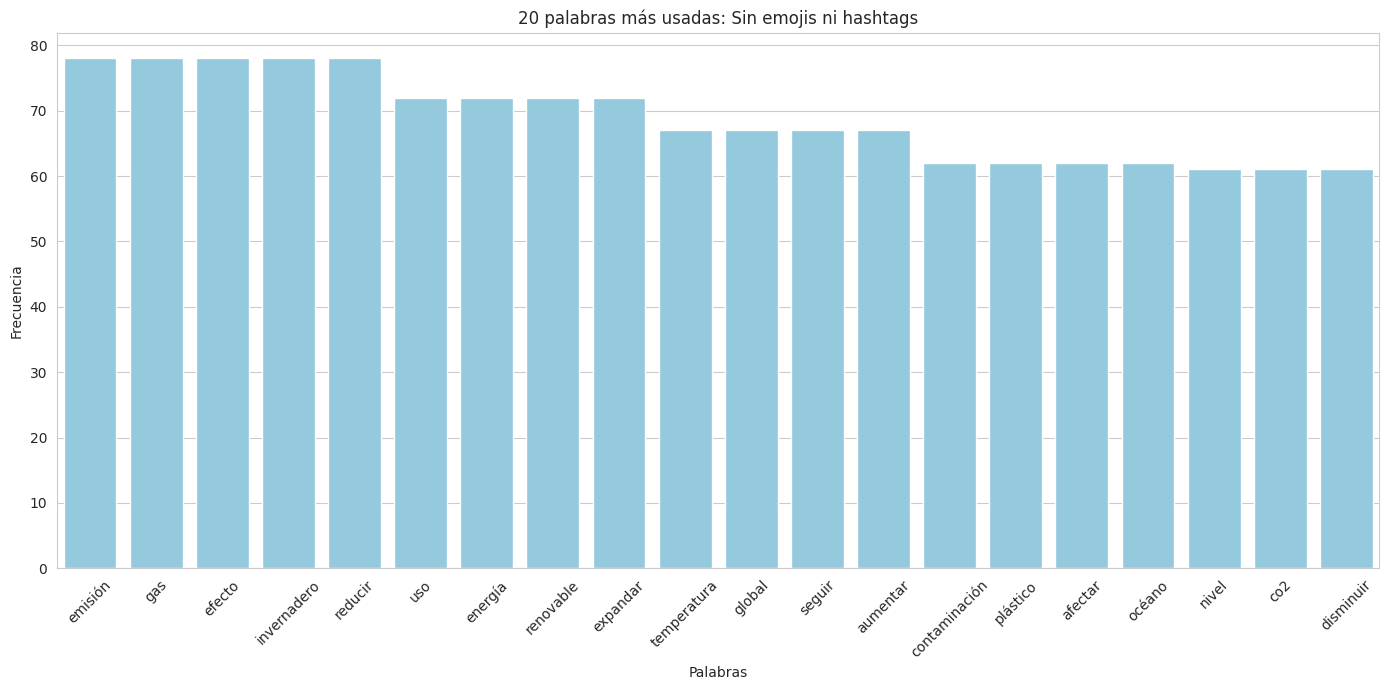

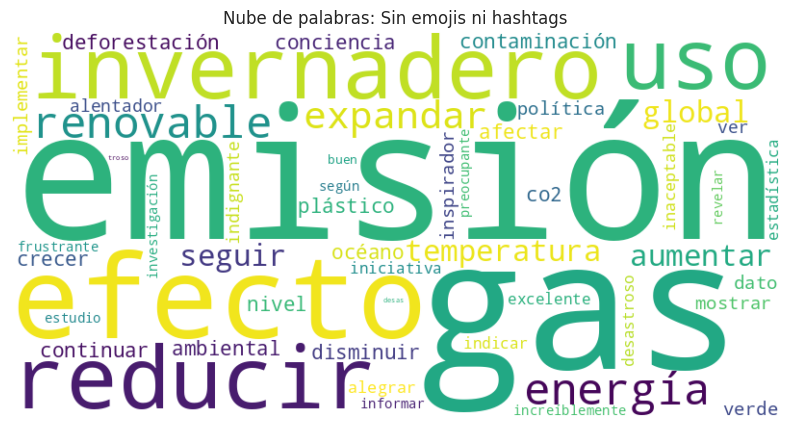

In [25]:
ejecutar_version(normalizar1,
                 "Sin emojis ni hashtags",
                 "skyblue",
                 "viridis")

# Versión 2: Emojis convertidos en texto, sin hashtags

[('emisión', 78), ('gas', 78), ('efecto', 78), ('invernadero', 78), ('reducir', 78), ('ola_de_mar', 77), ('uso', 72), ('energía', 72), ('renovable', 72), ('expandar', 72), ('advertencia', 71), ('corazón', 68), ('temperatura', 67), ('global', 67), ('seguir', 67), ('aumentar', 67), ('_verde', 67), ('fuego', 64), ('contaminación', 62), ('plástico', 62)]


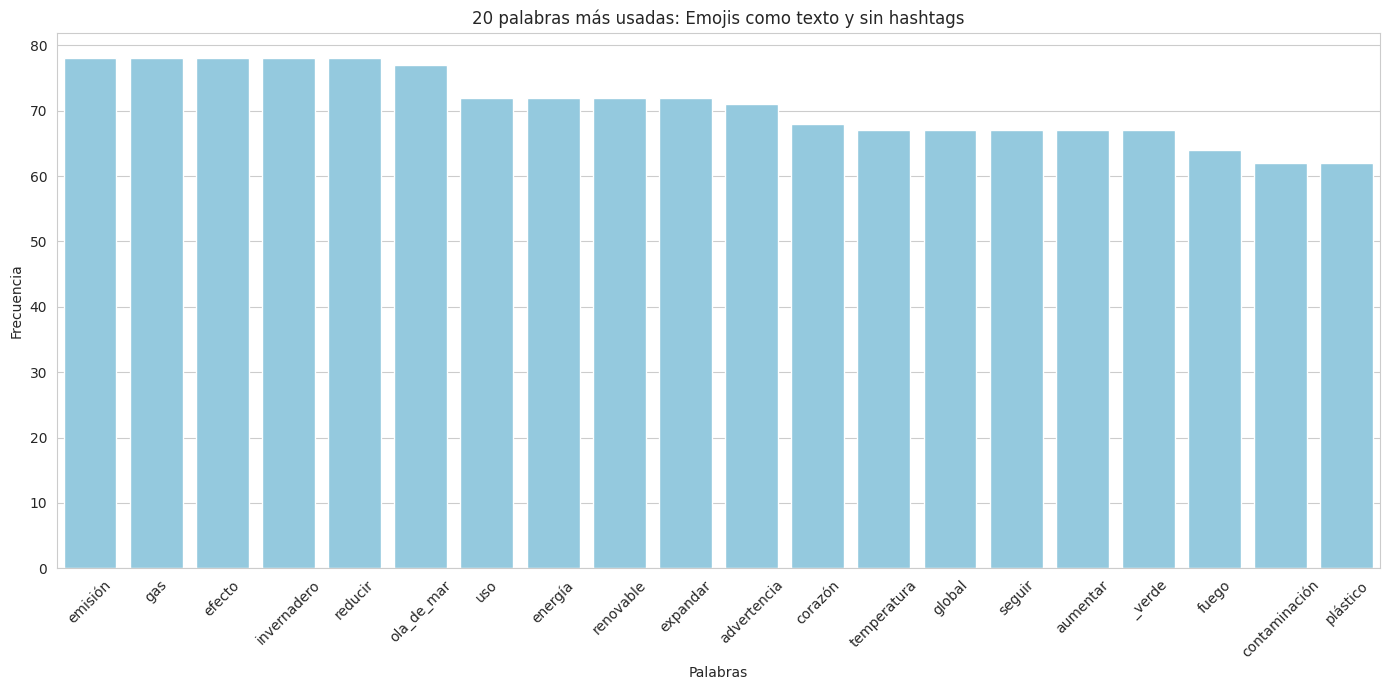

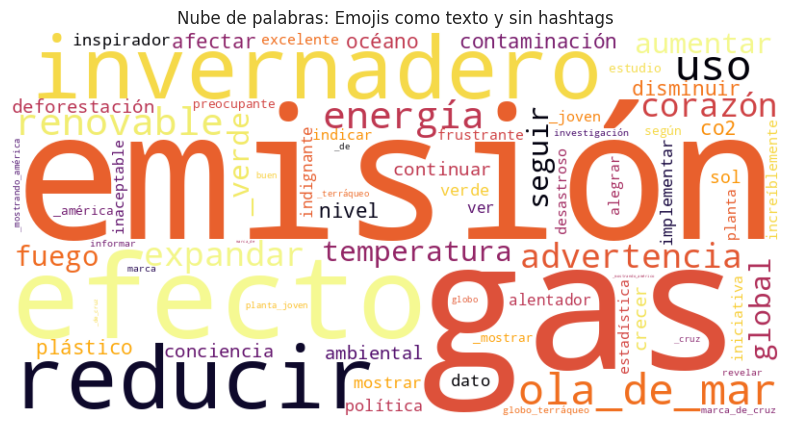

In [26]:
ejecutar_version(normalizar2,
                 "Emojis como texto y sin hashtags",
                 "skyblue",
                 "inferno")

# Versión 3: Emojis como texto y de los hashtags solo se elimina el `#`

[('ecoconciencia', 92), ('planeta', 84), ('cambioclimático', 82), ('medioambiente', 78), ('emisión', 78), ('gas', 78), ('efecto', 78), ('invernadero', 78), ('reducir', 78), ('ola_de_mar', 77), ('uso', 72), ('energía', 72), ('renovable', 72), ('expandar', 72), ('sostenibilidad', 72), ('advertencia', 71), ('corazón', 68), ('_verde', 68), ('temperatura', 67), ('global', 67)]


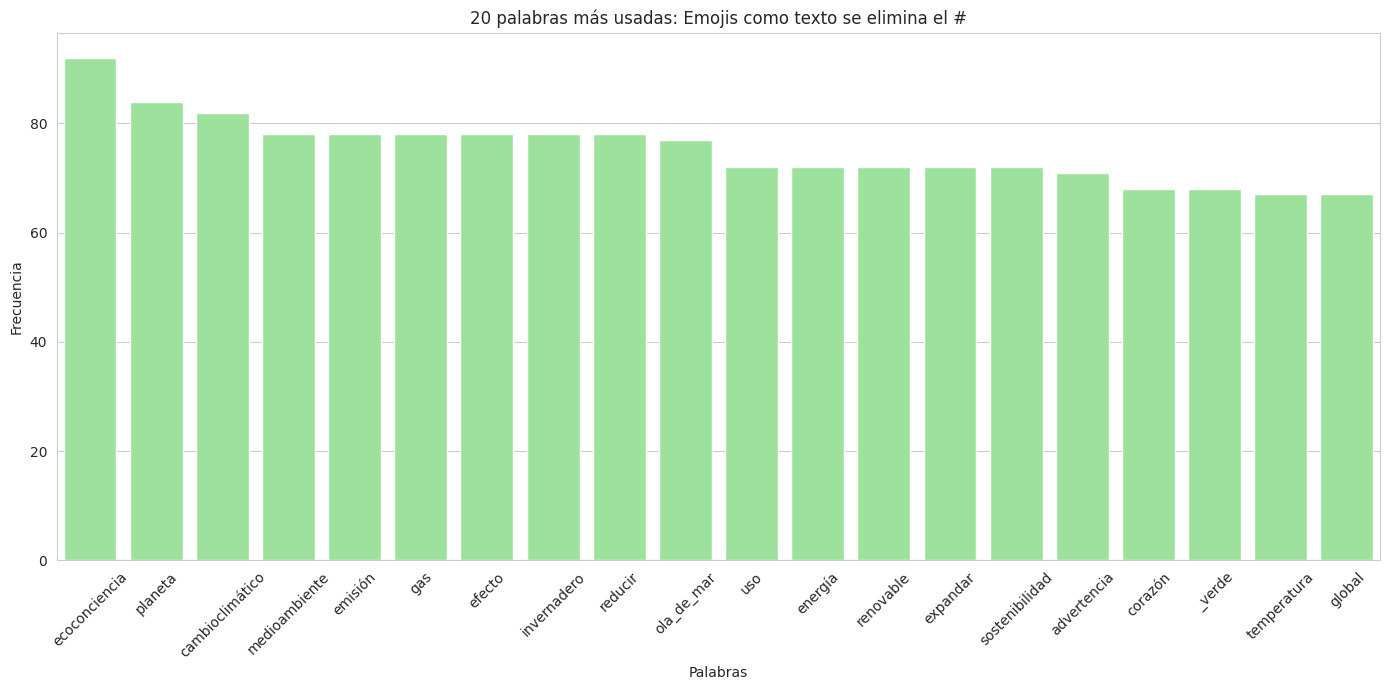

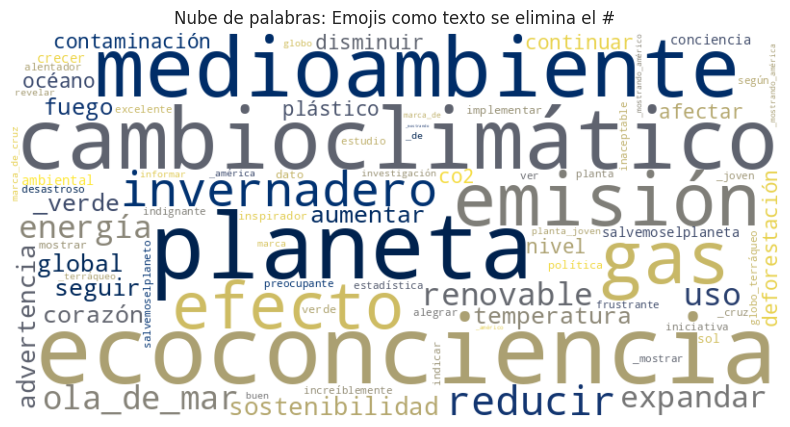

In [27]:
ejecutar_version(normalizar3,
                 "Emojis como texto se elimina el #",
                 "lightgreen",
                 "cividis")


**Conclusiones.** Prefiero la versión 1, que elimina los emojis y los hashtags, que aunque representan lemas o conceptos que se repiten, no tenemos la certeza de que dicha imagen (el emoji) o el uso del hashtag responda a un uso similar.